In [ ]:
# This opens a file picker — select your CSV file
from google.colab import files
uploaded = files.upload()

Saving Data_Science_Jobs_in_India.csv to Data_Science_Jobs_in_India (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Get the filename automatically
import io
filename = list(uploaded.keys())[0]
print(f"File loaded: {filename}")

# Load into DataFrame
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# First look — always do this before anything else
print(f"\n Shape: {df.shape}")
print(f" Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\n Column Names:")
for col in df.columns:
    print(f"   - {col}")

File loaded: Data_Science_Jobs_in_India (1).csv

 Shape: (1602, 8)
 Rows: 1602, Columns: 8

 Column Names:
   - Unnamed: 0
   - company_name
   - job_title
   - min_experience
   - avg_salary
   - min_salary
   - max_salary
   - num_of_salaries


In [ ]:
# See first 5 rows — like scrolling through Excel
print("=== FIRST 5 ROWS ===")
df.head()

=== FIRST 5 ROWS ===


,Unnamed: 0,company_name,job_title,min_experience,avg_salary,min_salary,max_salary,num_of_salaries
0,0,TCS,Data Scientist,2,7.8L,4.5L,16.0L,841
1,1,Accenture,Data Scientist,2,12.8L,5.8L,23.0L,501
2,2,IBM,Data Scientist,2,13.4L,5.3L,25.0L,394
3,3,Cognizant,Data Scientist,2,9.8L,5.0L,18.0L,318
4,4,Capgemini,Data Scientist,2,8.6L,4.8L,14.6L,300


In [ ]:
# Check data types and missing values
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
print(df[['avg_salary', 'min_salary', 'max_salary']].describe().round(2))

=== DATA TYPES ===
Unnamed: 0          int64
company_name       object
job_title          object
min_experience      int64
avg_salary         object
min_salary         object
max_salary         object
num_of_salaries     int64
dtype: object

=== MISSING VALUES ===
Unnamed: 0         0
company_name       0
job_title          0
min_experience     0
avg_salary         0
min_salary         0
max_salary         0
num_of_salaries    0
dtype: int64

=== BASIC STATISTICS ===
       avg_salary min_salary max_salary
count        1602       1602       1602
unique        305        197        304
top          9.7L       5.0L      20.0L
freq           16         62         63


In [ ]:
# See all unique job titles
print(f"Total unique job titles: {df['job_title'].nunique()}")
print("\nAll unique job titles:")
for title in sorted(df['job_title'].unique()):
    print(f"  - {title}")

Total unique job titles: 10

All unique job titles:
  - Business Analyst
  - Data Analyst
  - Data Architect
  - Data Engineer
  - Data Scientist
  - Machine Learning Engineer
  - Senior Business Analyst
  - Senior Data Analyst
  - Senior Data Engineer
  - Senior Data Scientist


In [ ]:
# Step 1: Drop the unnamed index column — it's useless
df = df.drop(columns=['Unnamed: 0'])
print("Dropped Unnamed column ✓")

# Step 2: Fix salary columns
# "9.7L" → remove "L" → "9.7" → convert to float → 9.7
def clean_salary(value):
    """
    This function takes "9.7L" and returns 9.7 (a number)
    .replace("L", "") removes the L
    float() converts string to decimal number
    """
    try:
        return float(str(value).replace("L", "").replace(",", "").strip())
    except:
        return None  # if something weird, return empty

# Apply the function to all 3 salary columns
df['avg_salary'] = df['avg_salary'].apply(clean_salary)
df['min_salary'] = df['min_salary'].apply(clean_salary)
df['max_salary'] = df['max_salary'].apply(clean_salary)

print("Salary columns cleaned ✓")
print("\nSample after cleaning:")
print(df[['avg_salary', 'min_salary', 'max_salary']].head(8))

Dropped Unnamed column ✓
Salary columns cleaned ✓

Sample after cleaning:
   avg_salary  min_salary  max_salary
0         7.8         4.5        16.0
1        12.8         5.8        23.0
2        13.4         5.3        25.0
3         9.8         5.0        18.0
4         8.6         4.8        14.6
5         9.3         4.5        24.0
6         9.7         4.5        18.2
7         7.6         4.1        15.4


In [ ]:
df.head()
df.dtypes

,0
company_name,object
job_title,object
min_experience,int64
avg_salary,float64
min_salary,float64
max_salary,float64
num_of_salaries,int64


In [ ]:
# Salary range = how wide is the pay band
# Example: min=6, max=15 → range = 9 LPA
df['salary_range'] = df['max_salary'] - df['min_salary']

print("Salary range column created ✓")
print(df[['min_salary', 'max_salary', 'salary_range']].head(5))

Salary range column created ✓
   min_salary  max_salary  salary_range
0         4.5        16.0          11.5
1         5.8        23.0          17.2
2         5.3        25.0          19.7
3         5.0        18.0          13.0
4         4.8        14.6           9.8


In [ ]:
# We create a mapping: job title → which sector it belongs to
# This is called Feature Engineering — creating new info from existing data

sector_map = {
    'Data Analyst':               'Analytics',
    'Senior Data Analyst':        'Analytics',
    'Business Analyst':           'Business Intelligence',
    'Senior Business Analyst':    'Business Intelligence',
    'Data Scientist':             'Data Science',
    'Senior Data Scientist':      'Data Science',
    'Machine Learning Engineer':  'ML Engineering',
    'Data Engineer':              'Data Engineering',
    'Senior Data Engineer':       'Data Engineering',
    'Data Architect':             'Data Architecture',
}

df['sector'] = df['job_title'].map(sector_map)

print("Sector column created ✓")
print("\nJobs per sector:")
print(df['sector'].value_counts())

Sector column created ✓

Jobs per sector:
sector
Business Intelligence    375
Analytics                374
Data Science             373
Data Engineering         371
ML Engineering            59
Data Architecture         50
Name: count, dtype: int64


In [ ]:
# Each job role typically needs specific skills
skills_map = {
    'Data Analyst':              ['Python', 'SQL', 'Excel', 'Tableau', 'Statistics'],
    'Senior Data Analyst':       ['Python', 'SQL', 'Tableau', 'Power BI', 'Statistics'],
    'Business Analyst':          ['SQL', 'Excel', 'Power BI', 'Communication', 'Statistics'],
    'Senior Business Analyst':   ['SQL', 'Excel', 'Power BI', 'Stakeholder Management'],
    'Data Scientist':            ['Python', 'Machine Learning', 'SQL', 'Statistics', 'Deep Learning'],
    'Senior Data Scientist':     ['Python', 'Machine Learning', 'Deep Learning', 'NLP', 'Statistics'],
    'Machine Learning Engineer': ['Python', 'TensorFlow', 'PyTorch', 'Deep Learning', 'MLOps'],
    'Data Engineer':             ['Python', 'SQL', 'Apache Spark', 'AWS', 'ETL'],
    'Senior Data Engineer':      ['Python', 'SQL', 'Apache Spark', 'Kafka', 'Cloud'],
    'Data Architect':            ['SQL', 'Data Modeling', 'Cloud', 'ETL', 'Architecture'],
}

df['skills'] = df['job_title'].map(skills_map)

print("Skills column created ✓")

# FIX: Convert list to string just for display — don't change the actual column
print("\nSample:")
sample = df[['job_title', 'skills']].copy()
sample['skills'] = sample['skills'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)
print(sample.drop_duplicates().to_string(index=False))

Skills column created ✓

Sample:
                job_title                                                   skills
           Data Scientist Python, Machine Learning, SQL, Statistics, Deep Learning
         Business Analyst          SQL, Excel, Power BI, Communication, Statistics
             Data Analyst                  Python, SQL, Excel, Tableau, Statistics
            Data Engineer                      Python, SQL, Apache Spark, AWS, ETL
    Senior Data Scientist Python, Machine Learning, Deep Learning, NLP, Statistics
  Senior Business Analyst             SQL, Excel, Power BI, Stakeholder Management
      Senior Data Analyst               Python, SQL, Tableau, Power BI, Statistics
     Senior Data Engineer                  Python, SQL, Apache Spark, Kafka, Cloud
Machine Learning Engineer        Python, TensorFlow, PyTorch, Deep Learning, MLOps
           Data Architect             SQL, Data Modeling, Cloud, ETL, Architecture


In [ ]:
# ═══════════════════════════════════════════════════════════
# MASTER SETUP CELL — Run this first every time you open Colab
# ═══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # select your CSV when prompted

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"✓ Loaded {df.shape[0]} rows, {df.shape[1]} columns")

# ── Clean ────────────────────────────────────────────────
df = df.drop(columns=['Unnamed: 0'])

def clean_salary(value):
    try:
        return float(str(value).replace("L", "").replace(",", "").strip())
    except:
        return None

df['avg_salary'] = df['avg_salary'].apply(clean_salary)
df['min_salary'] = df['min_salary'].apply(clean_salary)
df['max_salary'] = df['max_salary'].apply(clean_salary)
df['salary_range'] = df['max_salary'] - df['min_salary']
print("✓ Salary columns cleaned")

# ── Feature Engineering ──────────────────────────────────
sector_map = {
    'Data Analyst':              'Analytics',
    'Senior Data Analyst':       'Analytics',
    'Business Analyst':          'Business Intelligence',
    'Senior Business Analyst':   'Business Intelligence',
    'Data Scientist':            'Data Science',
    'Senior Data Scientist':     'Data Science',
    'Machine Learning Engineer': 'ML Engineering',
    'Data Engineer':             'Data Engineering',
    'Senior Data Engineer':      'Data Engineering',
    'Data Architect':            'Data Architecture',
}
df['sector'] = df['job_title'].map(sector_map)

skills_map = {
    'Data Analyst':              ['Python', 'SQL', 'Excel', 'Tableau', 'Statistics'],
    'Senior Data Analyst':       ['Python', 'SQL', 'Tableau', 'Power BI', 'Statistics'],
    'Business Analyst':          ['SQL', 'Excel', 'Power BI', 'Communication', 'Statistics'],
    'Senior Business Analyst':   ['SQL', 'Excel', 'Power BI', 'Stakeholder Management'],
    'Data Scientist':            ['Python', 'Machine Learning', 'SQL', 'Statistics', 'Deep Learning'],
    'Senior Data Scientist':     ['Python', 'Machine Learning', 'Deep Learning', 'NLP', 'Statistics'],
    'Machine Learning Engineer': ['Python', 'TensorFlow', 'PyTorch', 'Deep Learning', 'MLOps'],
    'Data Engineer':             ['Python', 'SQL', 'Apache Spark', 'AWS', 'ETL'],
    'Senior Data Engineer':      ['Python', 'SQL', 'Apache Spark', 'Kafka', 'Cloud'],
    'Data Architect':            ['SQL', 'Data Modeling', 'Cloud', 'ETL', 'Architecture'],
}
df['skills'] = df['job_title'].map(skills_map)

def categorize_experience(years):
    if years <= 2:
        return 'Fresher (0-2 yrs)'
    elif years <= 5:
        return 'Mid-Level (3-5 yrs)'
    else:
        return 'Senior (6+ yrs)'

df['experience_category'] = df['min_experience'].apply(categorize_experience)
print("✓ Feature engineering done")

# ── Final Check ──────────────────────────────────────────
print(f"\n✓ Dataset ready!")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")
print(f"\nExperience distribution:")
print(df['experience_category'].value_counts())
print(f"\nSalary stats:")
print(df[['avg_salary','min_salary','max_salary']].describe().round(2))

Saving Data_Science_Jobs_in_India.csv to Data_Science_Jobs_in_India (1).csv
✓ Loaded 1602 rows, 8 columns
✓ Salary columns cleaned
✓ Feature engineering done

✓ Dataset ready!
  Shape: (1602, 11)
  Columns: ['company_name', 'job_title', 'min_experience', 'avg_salary', 'min_salary', 'max_salary', 'num_of_salaries', 'salary_range', 'sector', 'skills', 'experience_category']

Experience distribution:
experience_category
Fresher (0-2 yrs)      884
Mid-Level (3-5 yrs)    549
Senior (6+ yrs)        169
Name: count, dtype: int64

Salary stats:
       avg_salary  min_salary  max_salary
count     1602.00     1602.00     1602.00
mean        13.23        8.63       19.14
std          7.84        5.80       11.15
min          1.40        0.20        2.00
25%          7.60        4.40       12.00
50%         11.90        7.00       18.00
75%         17.18       11.50       24.00
max         82.00       55.00      102.00


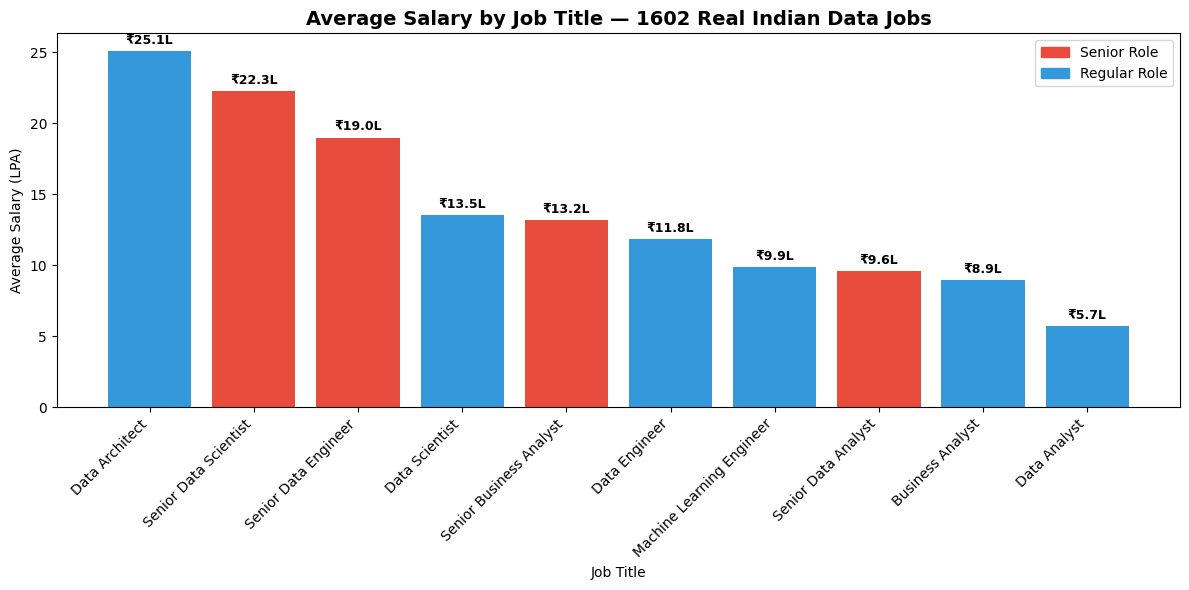

✓ Chart saved


In [ ]:
plt.figure(figsize=(12, 6))

salary_by_role = df.groupby('job_title')['avg_salary'].mean().sort_values(ascending=False)

colors = ['#e74c3c' if 'Senior' in x else '#3498db' for x in salary_by_role.index]
bars = plt.bar(range(len(salary_by_role)), salary_by_role.values, color=colors)

for bar, val in zip(bars, salary_by_role.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'₹{val:.1f}L',
        ha='center', va='bottom',
        fontweight='bold', fontsize=9
    )

plt.xticks(range(len(salary_by_role)), salary_by_role.index, rotation=45, ha='right')
plt.title('Average Salary by Job Title — 1602 Real Indian Data Jobs', fontsize=14, fontweight='bold')
plt.ylabel('Average Salary (LPA)')
plt.xlabel('Job Title')

from matplotlib.patches import Patch
legend = [
    Patch(color='#e74c3c', label='Senior Role'),
    Patch(color='#3498db', label='Regular Role')
]
plt.legend(handles=legend)
plt.tight_layout()
plt.savefig('salary_by_role.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

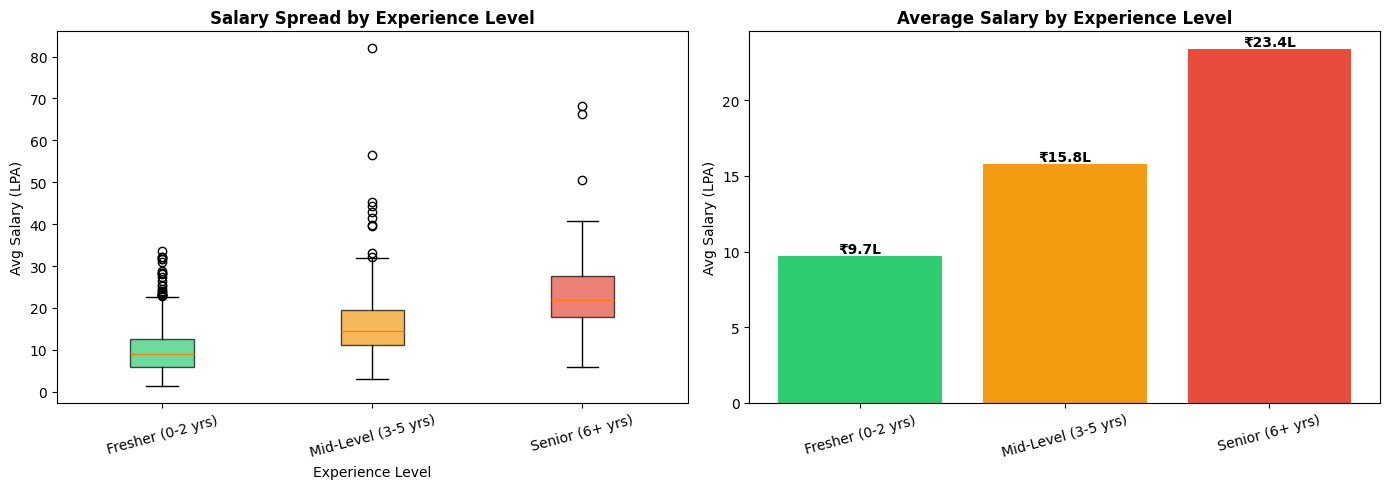

Average salary by experience:
  Fresher (0-2 yrs)         → ₹9.7 LPA  (884 jobs)
  Mid-Level (3-5 yrs)       → ₹15.8 LPA  (549 jobs)
  Senior (6+ yrs)           → ₹23.4 LPA  (169 jobs)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Fresher (0-2 yrs)', 'Mid-Level (3-5 yrs)', 'Senior (6+ yrs)']

# Chart 1 — Box plot (shows full spread of salaries)
groups = [df[df['experience_category'] == cat]['avg_salary'].dropna() for cat in order]
bp = axes[0].boxplot(groups, labels=order, patch_artist=True)
colors_box = ['#2ecc71', '#f39c12', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Salary Spread by Experience Level', fontweight='bold')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Avg Salary (LPA)')
axes[0].tick_params(axis='x', rotation=15)

# Chart 2 — Bar chart (shows average per level)
exp_avg = df.groupby('experience_category')['avg_salary'].mean().reindex(order)
bars = axes[1].bar(order, exp_avg.values, color=colors_box)
for bar, val in zip(bars, exp_avg.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'₹{val:.1f}L',
        ha='center', fontweight='bold', fontsize=10
    )
axes[1].set_title('Average Salary by Experience Level', fontweight='bold')
axes[1].set_ylabel('Avg Salary (LPA)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('salary_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()

# Print numbers too
print("Average salary by experience:")
for cat in order:
    avg = df[df['experience_category'] == cat]['avg_salary'].mean()
    count = len(df[df['experience_category'] == cat])
    print(f"  {cat:25s} → ₹{avg:.1f} LPA  ({count} jobs)")

=== SKILLS IN DEMAND ===
SQL                       1358
Python                    1177
Statistics                 935
Power BI                   562
Excel                      562
Deep Learning              432
Tableau                    374
Machine Learning           373
Apache Spark               371
ETL                        238
Cloud                      233
AWS                        188
Communication              188
Stakeholder Management     187
NLP                        185
Kafka                      183
TensorFlow                  59
PyTorch                     59
MLOps                       59
Data Modeling               50
Architecture                50
Name: count, dtype: int64


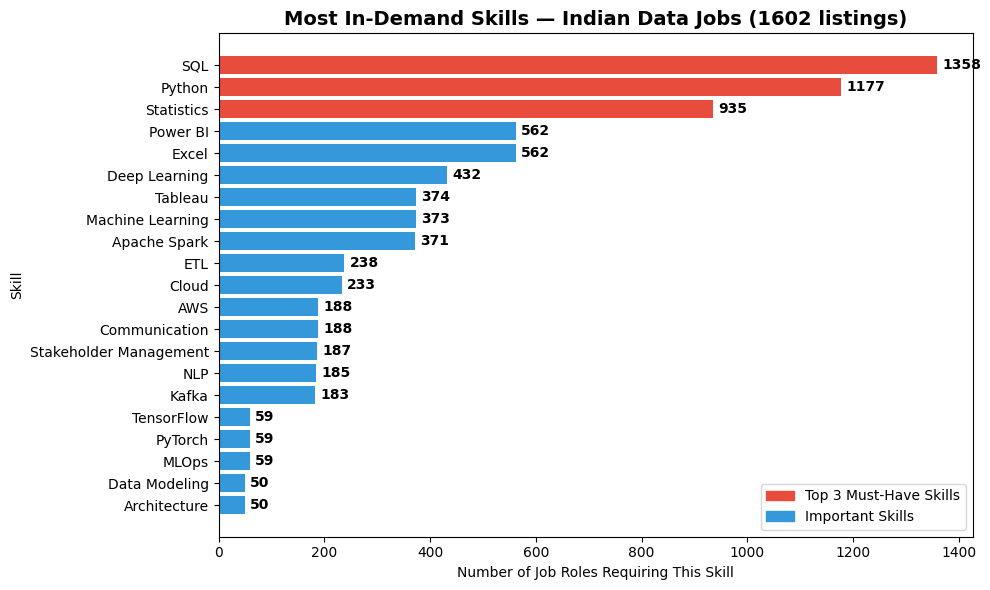

✓ Chart saved


In [ ]:
# Flatten all skills into one big list
all_skills = []
for skill_list in df['skills']:
    if isinstance(skill_list, list):
        all_skills.extend(skill_list)

skill_counts = pd.Series(all_skills).value_counts()

print("=== SKILLS IN DEMAND ===")
print(skill_counts)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(skill_counts))]
bars = plt.barh(skill_counts.index[::-1], skill_counts.values[::-1], color=colors[::-1])

for bar, val in zip(bars, skill_counts.values[::-1]):
    plt.text(val + 10, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold', fontsize=10)

plt.title('Most In-Demand Skills — Indian Data Jobs (1602 listings)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Roles Requiring This Skill')
plt.ylabel('Skill')

from matplotlib.patches import Patch
legend = [
    Patch(color='#e74c3c', label='Top 3 Must-Have Skills'),
    Patch(color='#3498db', label='Important Skills')
]
plt.legend(handles=legend)
plt.tight_layout()
plt.savefig('skills_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

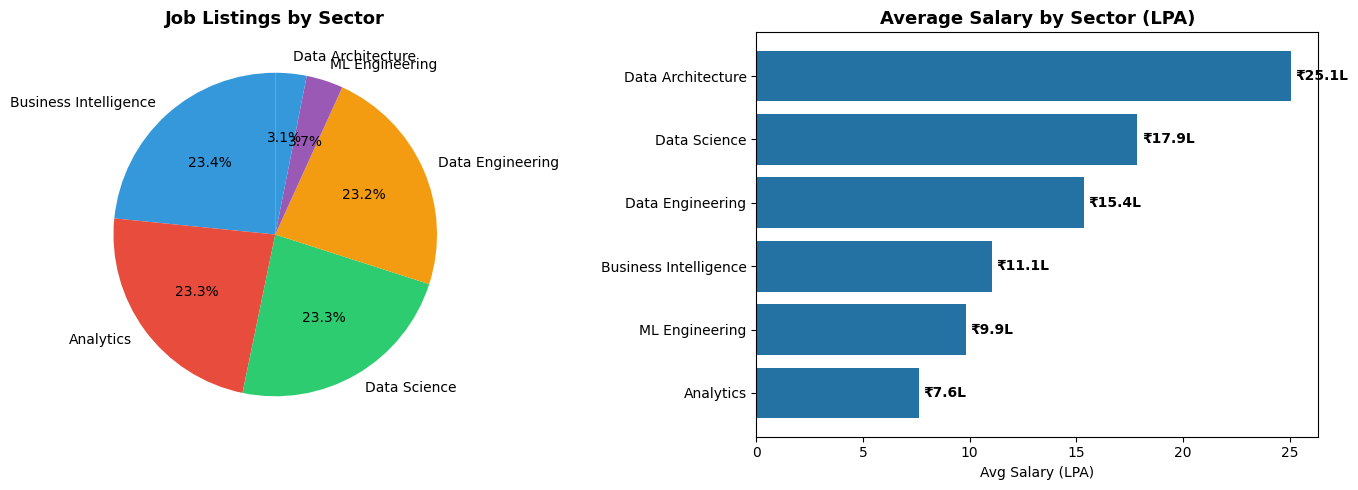

✓ Chart saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Pie chart: jobs count by sector
sector_counts = df['sector'].value_counts()
axes[0].pie(
    sector_counts.values,
    labels=sector_counts.index,
    autopct='%1.1f%%',
    colors=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'],
    startangle=90,
    textprops={'fontsize': 10}
)
axes[0].set_title('Job Listings by Sector', fontweight='bold', fontsize=13)

# Chart 2 — Bar chart: avg salary by sector
sector_salary = df.groupby('sector')['avg_salary'].mean().sort_values(ascending=True)
bars = axes[1].barh(sector_salary.index, sector_salary.values, color='#2471a3')
for bar, val in zip(bars, sector_salary.values):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'₹{val:.1f}L', va='center', fontweight='bold', fontsize=10)
axes[1].set_title('Average Salary by Sector (LPA)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Avg Salary (LPA)')

plt.tight_layout()
plt.savefig('sector_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

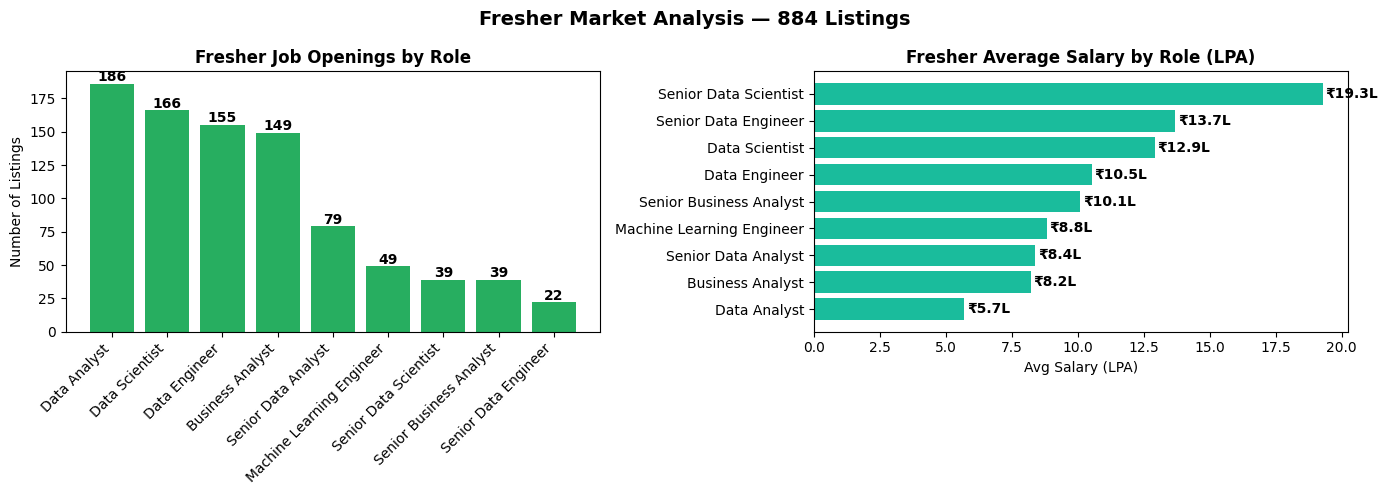

✓ Chart saved


In [ ]:
fresher_df = df[df['experience_category'] == 'Fresher (0-2 yrs)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Fresher jobs by role
fresher_role = fresher_df['job_title'].value_counts()
bars = axes[0].bar(range(len(fresher_role)), fresher_role.values, color='#27ae60')
axes[0].set_xticks(range(len(fresher_role)))
axes[0].set_xticklabels(fresher_role.index, rotation=45, ha='right')
for bar, val in zip(bars, fresher_role.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title('Fresher Job Openings by Role', fontweight='bold')
axes[0].set_ylabel('Number of Listings')

# Chart 2 — Fresher salary by role
fresher_sal = fresher_df.groupby('job_title')['avg_salary'].mean().sort_values(ascending=True)
bars2 = axes[1].barh(fresher_sal.index, fresher_sal.values, color='#1abc9c')
for bar, val in zip(bars2, fresher_sal.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'₹{val:.1f}L', va='center', fontweight='bold')
axes[1].set_title('Fresher Average Salary by Role (LPA)', fontweight='bold')
axes[1].set_xlabel('Avg Salary (LPA)')

plt.suptitle(f'Fresher Market Analysis — {len(fresher_df)} Listings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fresher_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

In [ ]:
print("=" * 60)
print("   KEY INSIGHTS — INDIAN DATA JOB MARKET (1602 jobs)")
print("=" * 60)

# Insight 1
top_role = df.groupby('job_title')['avg_salary'].mean().idxmax()
top_sal  = df.groupby('job_title')['avg_salary'].mean().max()
print(f"\n1. HIGHEST PAYING ROLE")
print(f"   {top_role}")
print(f"   Average: ₹{top_sal:.1f} LPA")

# Insight 2
most_jobs  = df['job_title'].value_counts().idxmax()
most_count = df['job_title'].value_counts().max()
print(f"\n2. MOST IN-DEMAND ROLE")
print(f"   {most_jobs} — {most_count} listings ({most_count/len(df)*100:.1f}% of market)")

# Insight 3
fresher = df[df['experience_category'] == 'Fresher (0-2 yrs)']
best_fresher_role = fresher.groupby('job_title')['avg_salary'].mean().idxmax()
best_fresher_sal  = fresher.groupby('job_title')['avg_salary'].mean().max()
print(f"\n3. FRESHER MARKET")
print(f"   {len(fresher)} fresher-friendly listings")
print(f"   Overall fresher avg salary: ₹{fresher['avg_salary'].mean():.1f} LPA")
print(f"   Best fresher role: {best_fresher_role} @ ₹{best_fresher_sal:.1f} LPA avg")

# Insight 4
senior  = df[df['experience_category'] == 'Senior (6+ yrs)']
premium = ((senior['avg_salary'].mean() - fresher['avg_salary'].mean())
           / fresher['avg_salary'].mean() * 100)
print(f"\n4. EXPERIENCE PREMIUM")
print(f"   Fresher avg:    ₹{fresher['avg_salary'].mean():.1f} LPA")
print(f"   Mid-level avg:  ₹{df[df['experience_category']=='Mid-Level (3-5 yrs)']['avg_salary'].mean():.1f} LPA")
print(f"   Senior avg:     ₹{senior['avg_salary'].mean():.1f} LPA")
print(f"   Senior earns {premium:.0f}% more than freshers")

# Insight 5
print(f"\n5. TOP 3 MUST-HAVE SKILLS")
for i, (skill, count) in enumerate(skill_counts.head(3).items(), 1):
    pct = count / len(all_skills) * 100
    print(f"   {i}. {skill} — {pct:.1f}% of all skill mentions")

# Insight 6
high_pay = df['avg_salary'].quantile(0.75)
print(f"\n6. TO BREAK INTO TOP 25% SALARY (₹{high_pay:.0f}+ LPA)")
top_jobs = df[df['avg_salary'] >= high_pay]['job_title'].value_counts()
print(f"   These roles dominate high pay:")
for role, count in top_jobs.items():
    print(f"   → {role}: {count} listings")

print("\n" + "=" * 60)

   KEY INSIGHTS — INDIAN DATA JOB MARKET (1602 jobs)

1. HIGHEST PAYING ROLE
   Data Architect
   Average: ₹25.1 LPA

2. MOST IN-DEMAND ROLE
   Data Scientist — 188 listings (11.7% of market)

3. FRESHER MARKET
   884 fresher-friendly listings
   Overall fresher avg salary: ₹9.7 LPA
   Best fresher role: Senior Data Scientist @ ₹19.3 LPA avg

4. EXPERIENCE PREMIUM
   Fresher avg:    ₹9.7 LPA
   Mid-level avg:  ₹15.8 LPA
   Senior avg:     ₹23.4 LPA
   Senior earns 140% more than freshers

5. TOP 3 MUST-HAVE SKILLS
   1. SQL — 17.4% of all skill mentions
   2. Python — 15.0% of all skill mentions
   3. Statistics — 12.0% of all skill mentions

6. TO BREAK INTO TOP 25% SALARY (₹17+ LPA)
   These roles dominate high pay:
   → Senior Data Scientist: 138 listings
   → Senior Data Engineer: 97 listings
   → Data Architect: 45 listings
   → Data Scientist: 36 listings
   → Senior Business Analyst: 33 listings
   → Data Engineer: 28 listings
   → Senior Data Analyst: 14 listings
   → Machine L

In [ ]:
from google.colab import files

df.to_csv('jobs_cleaned.csv', index=False)

for fname in ['jobs_cleaned.csv', 'salary_by_role.png',
              'salary_by_experience.png', 'skills_demand.png',
              'sector_analysis.png', 'fresher_analysis.png']:
    files.download(fname)
    print(f"✓ Downloaded {fname}")

print("\nSave all these files in your project folder!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded jobs_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Downloaded sector_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded fresher_analysis.png

Save all these files in your project folder!
